In [118]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
import shap
from librosa.sequence import dtw
from IPython.display import Audio, display
from scipy.spatial.distance import cosine

In [119]:
def preprocess_audio(audio_path, sr=16000):
    # Load audio file
    audio, sr = librosa.load(audio_path, sr=sr)
    
    # Noise reduction (simple mean subtraction)
    audio_denoised = audio - np.mean(audio)
    
    # Generate spectrogram
    stft = librosa.stft(audio_denoised, n_fft=1024, hop_length=512, window='hamming')
    spectrogram = np.abs(stft)
    
    # Convert amplitude to decibel scale
    spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)
    spectrogram_normalized = spectrogram / np.max(spectrogram)
    
    return spectrogram_normalized, audio_denoised, spectrogram_db, sr

In [120]:
# Example usage
audio_path = "recording_1.wav"
spectrogram, audio, spectrogram_db, sr = preprocess_audio(audio_path)

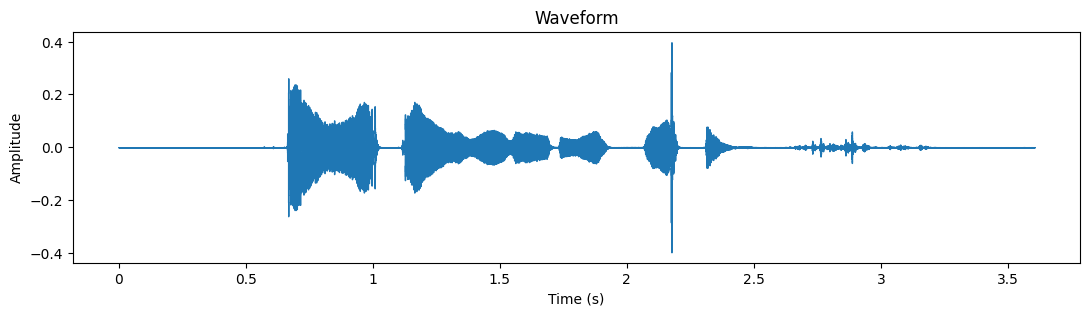

In [121]:
# 1. Plot Waveform
plt.figure(figsize=(13, 3))
librosa.display.waveshow(audio, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

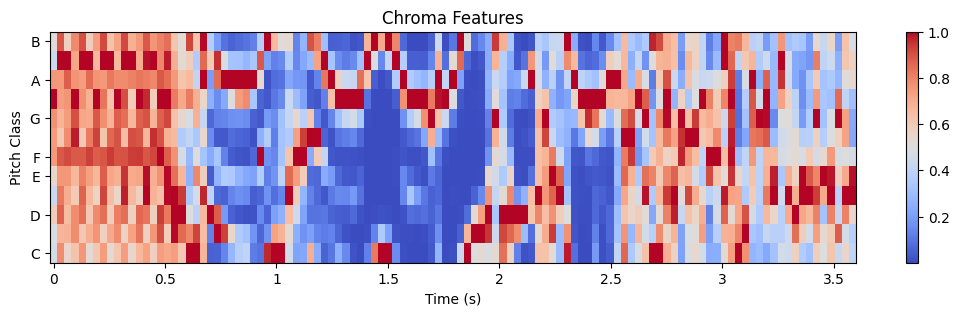

In [122]:
# 2. Plot Chroma Features
chroma = librosa.feature.chroma_stft(y=audio, sr=sr, n_fft=1024, hop_length=512)

plt.figure(figsize=(13, 3))
librosa.display.specshow(chroma, sr=sr, hop_length=512, x_axis='time', y_axis='chroma', cmap='coolwarm')
plt.colorbar()
plt.title("Chroma Features")
plt.xlabel("Time (s)")
plt.ylabel("Pitch Class")
plt.show()

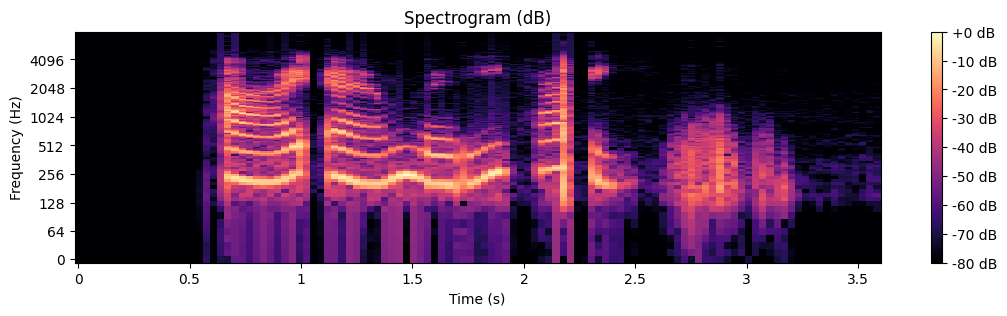

In [123]:
# 3. Plot Spectrogram
plt.figure(figsize=(13, 3))
librosa.display.specshow(spectrogram_db, sr=sr, hop_length=512, x_axis='time', y_axis='log', cmap='magma')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()

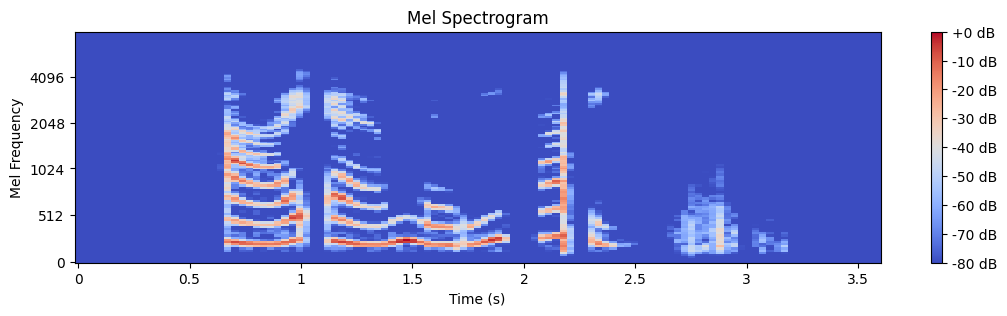

In [124]:
# 3. Plot Mel Spectrogram
mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=1024, hop_length=512, n_mels=128)
mel_spectrogram_db = librosa.amplitude_to_db(mel_spectrogram, ref=np.max)

plt.figure(figsize=(13, 3))
librosa.display.specshow(mel_spectrogram_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel', cmap='coolwarm')
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Mel Frequency")
plt.show()

In [125]:
# Function to apply NMF
def apply_nmf(spectrogram, n_components=10):
    model = NMF(n_components=n_components, init='random', random_state=42, max_iter=1500)
    W = model.fit_transform(spectrogram)
    H = model.components_
    return W, H

In [126]:
# Apply NMF on the non-negative spectrogram
n_components = 6
W, H = apply_nmf(spectrogram, n_components=n_components)

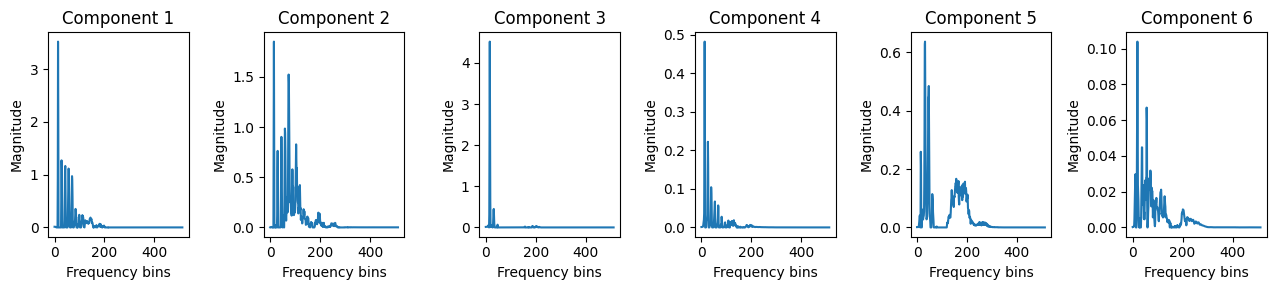

In [127]:
# Plot basis components (W)
plt.figure(figsize=(13, 3))
for i in range(n_components):
    plt.subplot(1, n_components, i + 1)
    plt.plot(W[:, i])
    plt.title(f"Component {i+1}")
    plt.xlabel("Frequency bins")
    plt.ylabel("Magnitude")
plt.tight_layout()
plt.show()

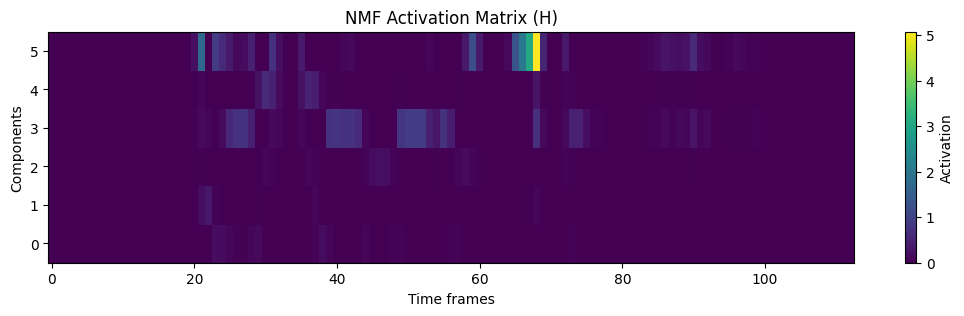

In [128]:
# Plot activation matrix (H)
plt.figure(figsize=(13, 3))
plt.imshow(H, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label="Activation")
plt.title("NMF Activation Matrix (H)")
plt.xlabel("Time frames")
plt.ylabel("Components")
plt.show()

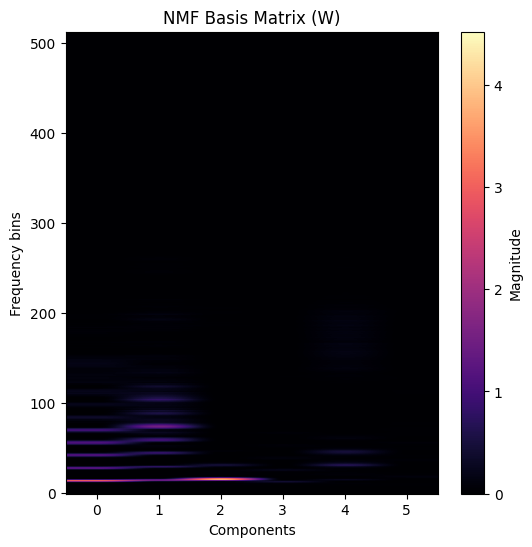

In [129]:
# Visualize W as a heatmap
plt.figure(figsize=(6, 6))
plt.imshow(W, aspect='auto', cmap='magma', origin='lower')
plt.colorbar(label="Magnitude")
plt.title("NMF Basis Matrix (W)")
plt.xlabel("Components")
plt.ylabel("Frequency bins")
plt.show()

In [131]:
def segment_activations(H, sr, hop_length=512, threshold_factor=0.1, visualize=False):
    phoneme_boundaries = []
    time_axis = librosa.frames_to_time(np.arange(H.shape[1]), sr=sr, hop_length=hop_length)

    for component in range(H.shape[0]):
        activations = H[component, :]
        threshold = threshold_factor * np.max(activations)
        
        # Identify frames where activation exceeds threshold
        peaks = np.where(activations > threshold)[0]
        if len(peaks) > 0:
            times = librosa.frames_to_time(peaks, sr=sr, hop_length=hop_length)
            phoneme_boundaries.append((component, times))
        else:
            phoneme_boundaries.append((component, []))  # No activations found

        # Visualization mode
        if visualize:
            plt.figure(figsize=(12, 4))
            plt.plot(time_axis, activations, label=f"Component {component + 1}")
            plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold')
            if len(peaks) > 0:
                for peak in peaks:
                    plt.axvline(x=librosa.frames_to_time(peak, sr=sr, hop_length=hop_length),
                                color='green', linestyle='--', alpha=0.7)
            plt.title(f"Phoneme Activations for Component {component + 1}")
            plt.xlabel("Time (s)")
            plt.ylabel("Activation")
            plt.legend()
            plt.tight_layout()
            plt.show()

    # Printing mode
    if not visualize:
        for comp, times in phoneme_boundaries:
            if len(times) > 0:
                print(f"Phoneme {comp}: {times}")
            else:
                print(f"Phoneme {comp}: No significant activations")

    return phoneme_boundaries

In [132]:
boundaries = segment_activations(H, sr)

Phoneme 0: [0.736 0.768 0.8   0.832 0.864 0.896 0.928 1.12  1.184 1.216 1.248 1.376
 1.408 1.44  1.536 1.568 1.792 1.824 2.336]
Phoneme 1: [0.672 0.704 0.736 1.184 2.176]
Phoneme 2: [0.672 0.96  0.992 1.152 1.184 1.408 1.44  1.472 1.504 1.536 1.728 1.824
 1.856 1.888 1.92  2.304 2.336 2.88 ]
Phoneme 3: [0.672 0.768 0.8   0.832 0.864 0.896 0.992 1.248 1.28  1.312 1.344 1.376
 1.568 1.6   1.632 1.664 1.696 1.728 1.76  1.792 2.176 2.208 2.304 2.336
 2.368 2.4   2.752 2.816 2.88  2.912 2.944]
Phoneme 4: [0.672 0.928 0.96  0.992 1.024 1.12  1.152 1.184 1.216 2.176]
Phoneme 5: [0.672 0.736 0.768 0.992 1.888 2.08  2.112 2.144 2.176 2.208 2.88 ]


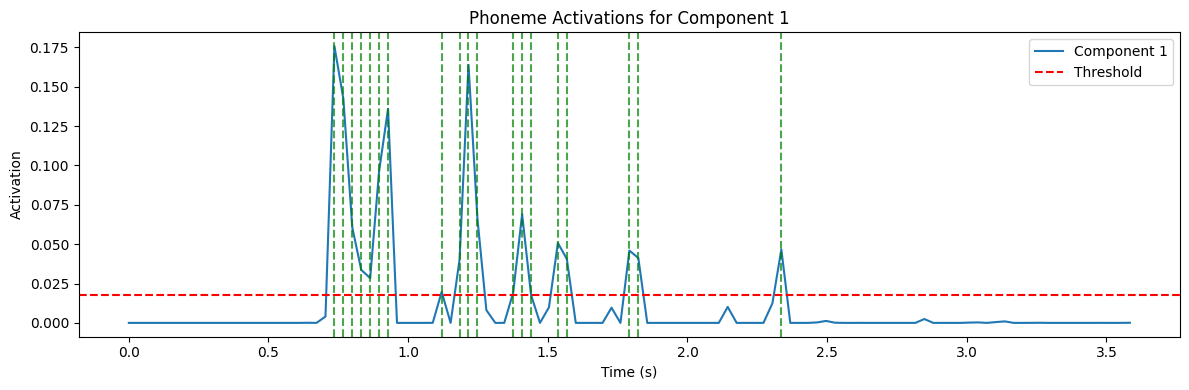

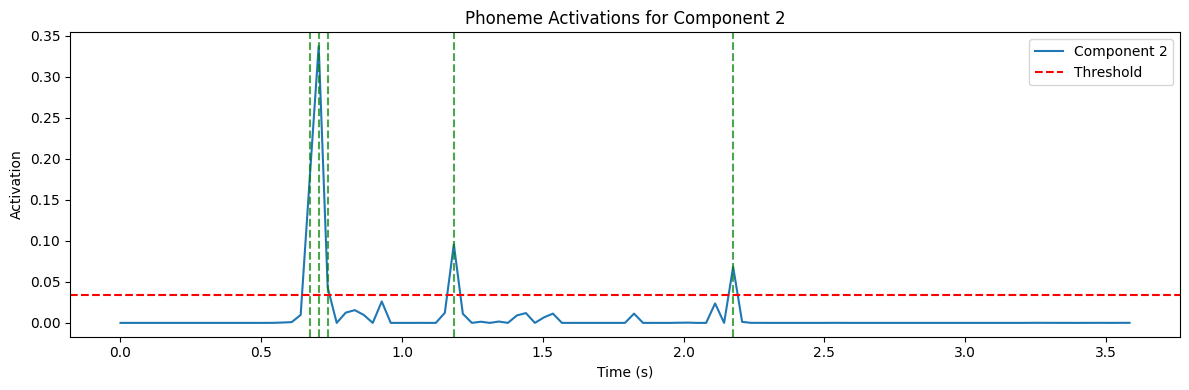

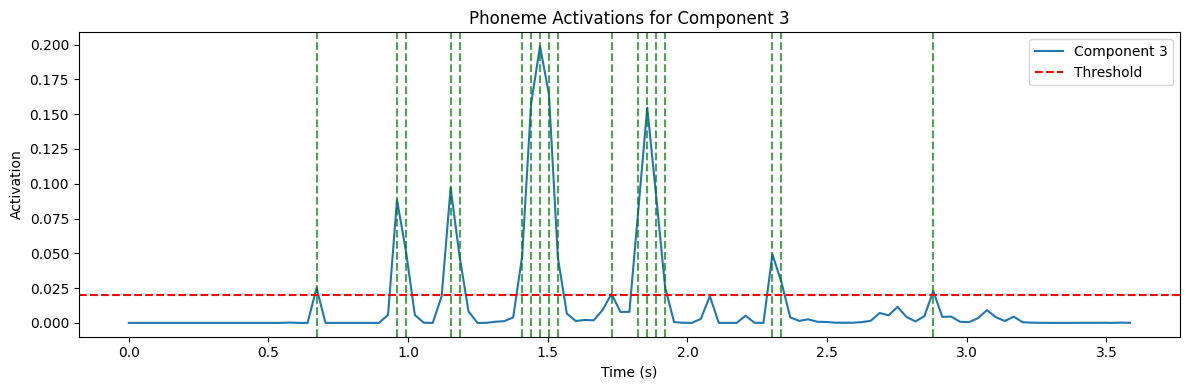

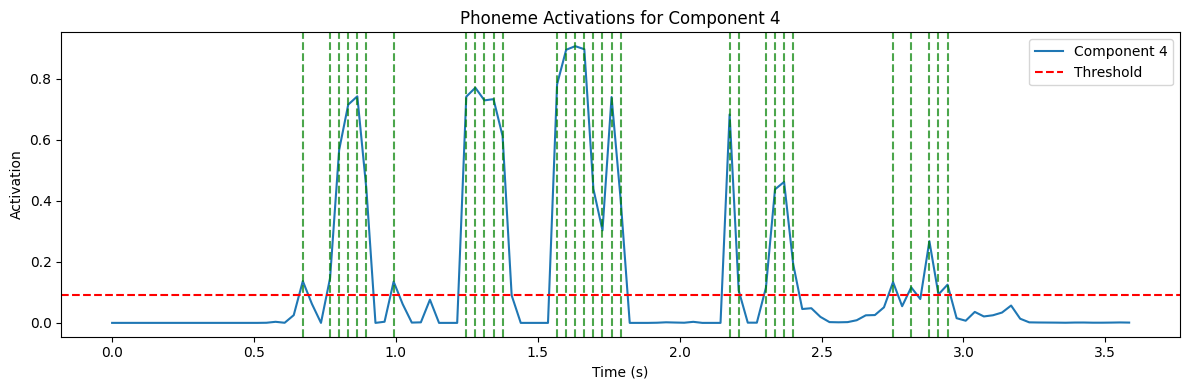

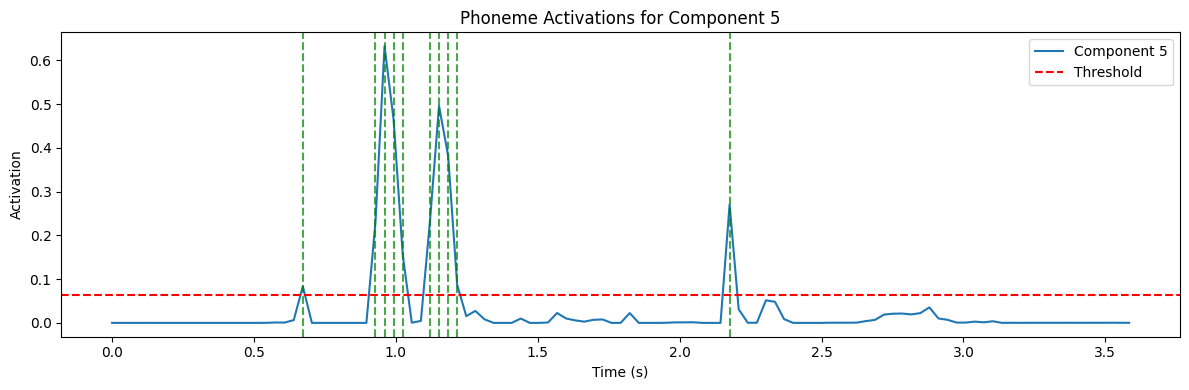

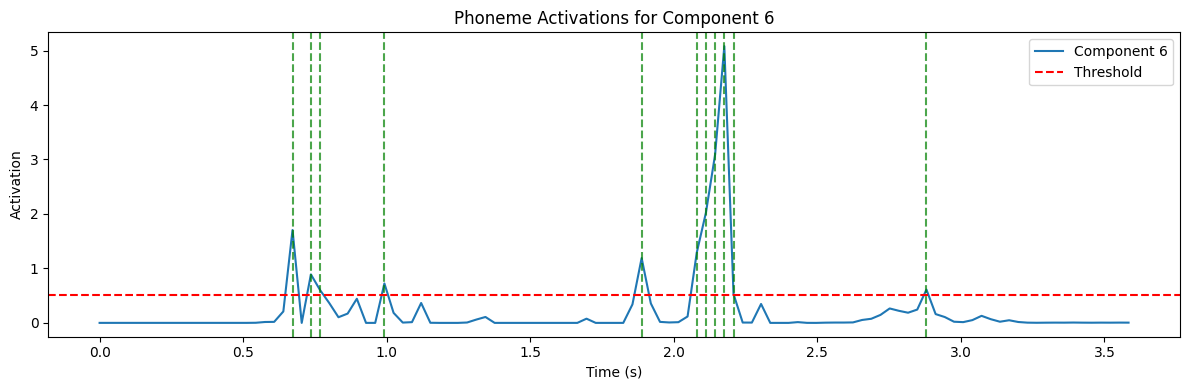

In [133]:
boundaries = segment_activations(H, sr, visualize=True)

In [134]:
print(f"W shape: {W.shape}")
print(f"H shape: {H.shape}")
print(f"Spectrogram shape: {spectrogram.shape}")

W shape: (513, 6)
H shape: (6, 113)
Spectrogram shape: (513, 113)


In [135]:
def explain_segmentation(W, H, component=0, min_evals=None):
    num_features = W.shape[0]  # Number of features in W
    if min_evals is None:
        min_evals = 2 * num_features + 1  # Minimum required max_evals

    # Feature importance based on component's basis vector
    def model(x):
        return np.dot(x, W[:, component])
    
    # Create SHAP explainer
    explainer = shap.Explainer(model, W.T, max_evals=min_evals)
    
    # Generate SHAP values
    shap_values = explainer(W.T)
    
    # Get the activation weights for the selected component
    component_weights = H[component, :]
    
    return shap_values, component_weights

# Example usage
shap_values, component_weights = explain_segmentation(W, H, component=0)

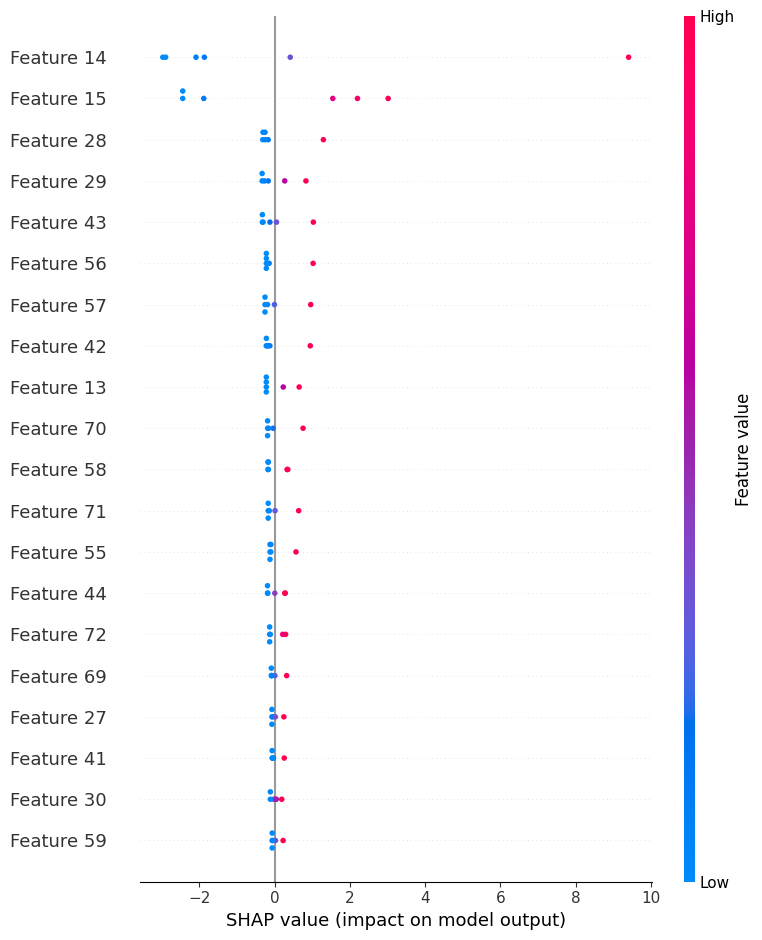

In [136]:
shap.summary_plot(shap_values, W.T, show=True)

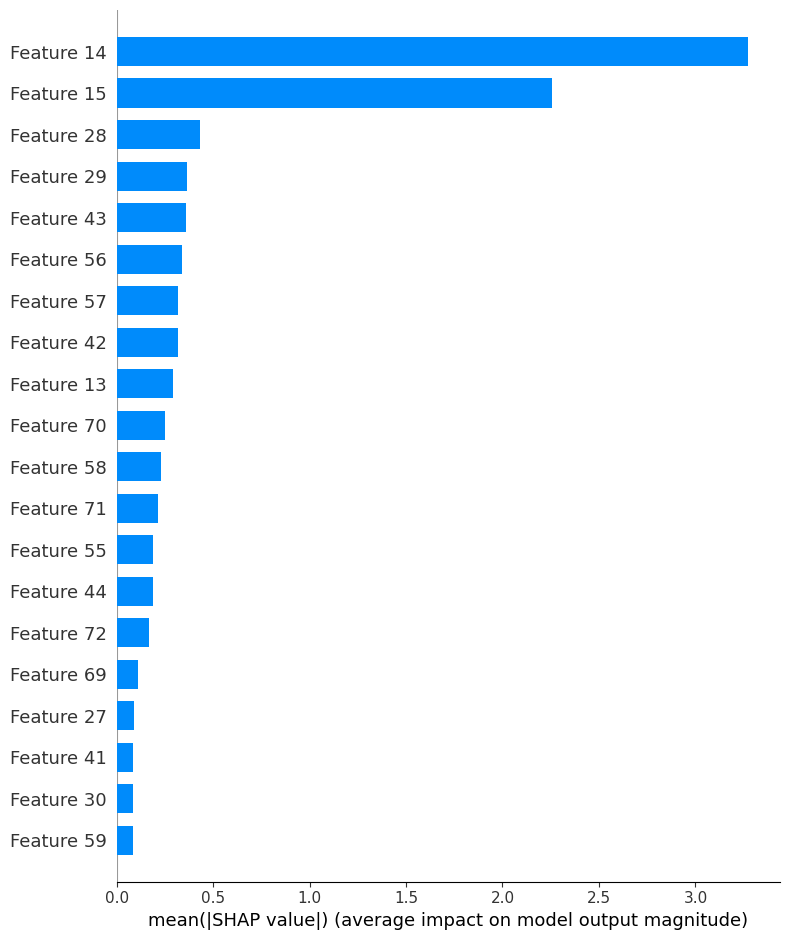

In [137]:
shap.summary_plot(shap_values, W.T, plot_type="bar", show=True)

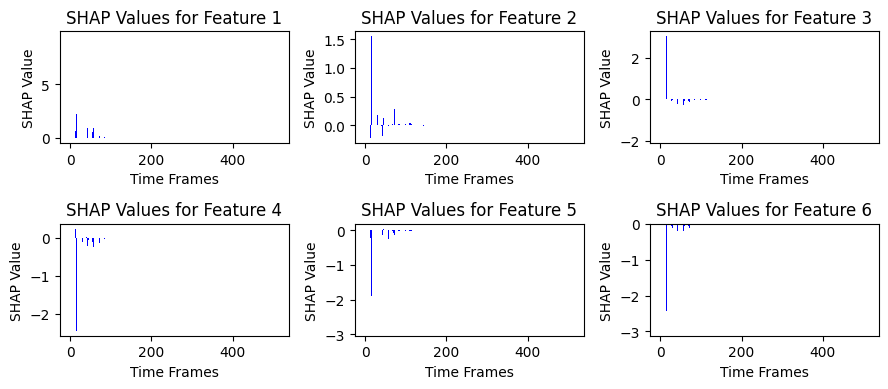

In [138]:
def plot_shap_for_features_grid(shap_values, num_features_to_show=5, grid_size=(2, 3)):
    num_plots = min(num_features_to_show, shap_values.shape[0])
    rows, cols = grid_size
    
    # Create a figure with subplots
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2))
    axes = axes.flatten()  # Flatten axes array for easy indexing

    for i in range(num_plots):
        ax = axes[i]
        ax.bar(range(len(shap_values.values[i])), shap_values.values[i], color='blue')
        ax.set_xlabel("Time Frames")
        ax.set_ylabel("SHAP Value")
        ax.set_title(f"SHAP Values for Feature {i + 1}")

    # Hide any extra subplots
    for j in range(num_plots, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
plot_shap_for_features_grid(shap_values, num_features_to_show=6, grid_size=(2, 3))  # Adjust grid size as needed

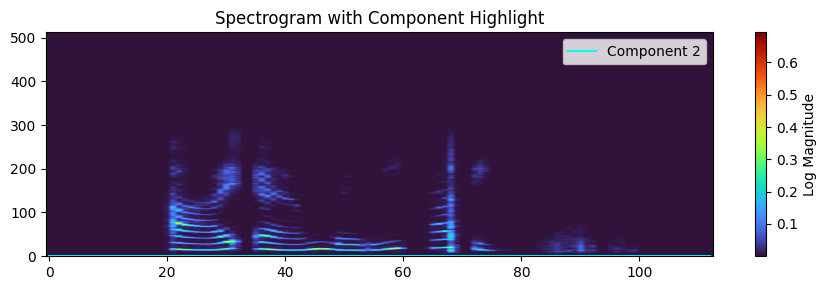

In [145]:
component=1
plt.figure(figsize=(9, 3))
plt.imshow(np.log1p(spectrogram), aspect='auto', origin='lower', cmap='turbo')
plt.title("Spectrogram with Component Highlight")
plt.colorbar(label="Log Magnitude")
plt.plot(component_weights, label=f"Component {component + 1}", color="cyan")
plt.legend()
plt.tight_layout()
plt.show()

In [142]:
def refine_boundaries(spectrogram, template_spectrogram):
    # Perform DTW
    D, wp = dtw(spectrogram, template_spectrogram, subseq=True, metric='euclidean')
    refined_boundaries = wp[:, 0]  # Extract refined boundaries
    return refined_boundaries, wp

In [143]:
# Example usage
template = spectrogram[:, 19:91]  # Assume first 50 frames are a template
refined, wp = refine_boundaries(spectrogram, template)
print("Refined Segmentation Results:", refined)

Refined Segmentation Results: [90 89 88 87 86 85 84 83 82 81 80 79 78 77 76 75 74 73 72 71 70 69 68 67
 66 65 64 63 62 61 60 59 58 57 56 55 54 53 52 51 50 49 48 47 46 45 44 43
 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 19]


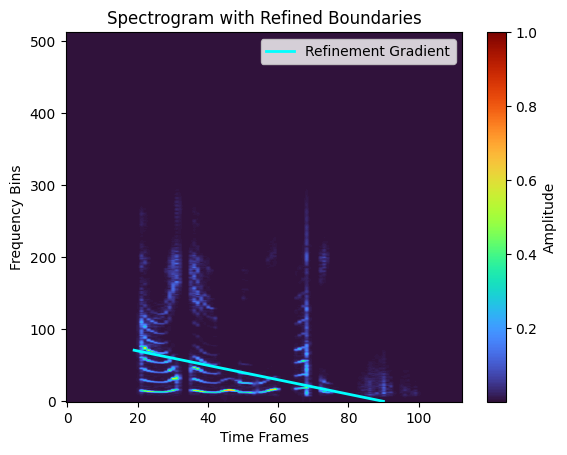

In [144]:
plt.imshow(spectrogram, aspect='auto', origin='lower', cmap='turbo')
plt.plot(refined, np.arange(len(refined)), color='cyan', label='Refinement Gradient', linewidth=2)
plt.colorbar(label='Amplitude')
plt.title("Spectrogram with Refined Boundaries")
plt.xlabel("Time Frames")
plt.ylabel("Frequency Bins")
plt.legend()
plt.show()

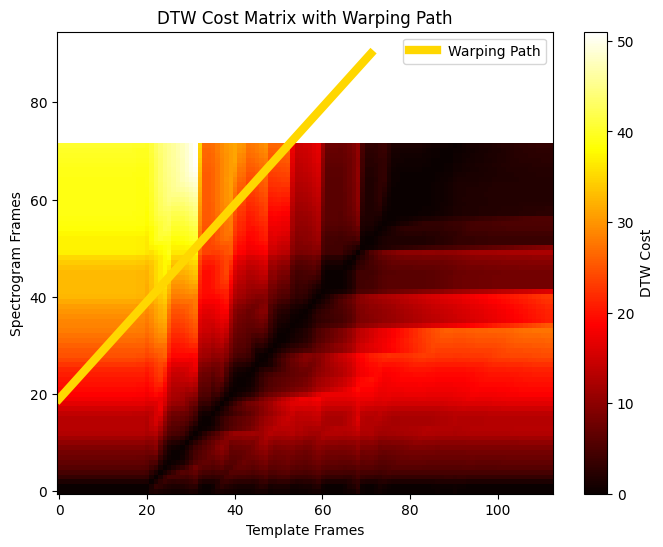

In [76]:
D, wp = dtw(spectrogram, template, subseq=True, metric='euclidean')

plt.figure(figsize=(8, 6))
plt.imshow(D, origin='lower', aspect='auto', cmap='hot', interpolation='nearest')
plt.plot(wp[:, 1], wp[:, 0], color='gold', label='Warping Path', linewidth=6)
plt.colorbar(label='DTW Cost')
plt.title("DTW Cost Matrix with Warping Path")
plt.xlabel("Template Frames")
plt.ylabel("Spectrogram Frames")
plt.legend()
plt.show()

In [110]:
def harness(y, sr, frame_length=1375, hop_length=512, zcr_threshold=0.2, ste_threshold=0.01):
    # Compute features
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=frame_length, hop_length=hop_length)[0]
    frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length)
    ste = np.sum(frames**2, axis=0)

    # Normalize features
    zcr_norm = zcr / np.max(zcr)
    ste_norm = ste / np.max(ste)

    word_boundaries = []
    in_segment = False
    for i, (z, e) in enumerate(zip(zcr_norm, ste_norm)):
        if z > zcr_threshold or e > ste_threshold:
            if not in_segment:
                in_segment = True
                start_time = i * hop_length / sr
        else:
            if in_segment:
                in_segment = False
                end_time = i * hop_length / sr
                word_boundaries.append((start_time, end_time))
    
    # Extract segments
    segments = []
    for start, end in word_boundaries:
        start_sample = int(start * sr)
        end_sample = int(end * sr)
        segments.append((start, end, y[start_sample:end_sample]))
    return segments, zcr_norm, ste_norm, word_boundaries

In [111]:
file_path = "recording_1.wav"  # Replace with the path to your WAV file
word_audio, sr = librosa.load(file_path, sr=16000)
segments, zcr_norm, ste_norm, boundaries = harness(word_audio, sr)

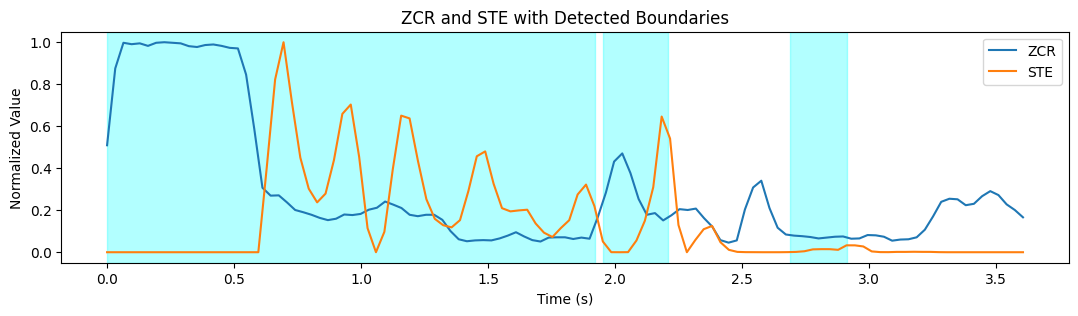

In [115]:
min_d = 0.2  # Minimum duration for a segment in seconds
# Plot ZCR and STE
plt.figure(figsize=(13, 3))
plt.plot(np.linspace(0, len(word_audio)/sr, len(zcr_norm)), zcr_norm, label="ZCR")
plt.plot(np.linspace(0, len(word_audio)/sr, len(ste_norm)), ste_norm, label="STE")
plt.xlabel("Time (s)")
plt.ylabel("Normalized Value")
plt.title("ZCR and STE with Detected Boundaries")
plt.legend()
for start, end in boundaries:
    duration = end - start
    if duration >= min_d:
        plt.axvspan(start, end, color="cyan", alpha=0.3)  # Highlight valid segments
plt.show()

In [116]:
print("Detected Words:")
for i, (start, end, segment) in enumerate(segments):
    duration = end - start
    if duration < min_d:
        continue  # Skip segments shorter than the minimum duration

    # Display segment details and audio
    print(f"Word {i+1}: Start = {start:.2f}s, End = {end:.2f}s, Duration = {duration:.2f}s")
    display(Audio(segment, rate=sr))

Detected Words:
Word 1: Start = 0.00s, End = 1.92s, Duration = 1.92s


Word 2: Start = 1.95s, End = 2.21s, Duration = 0.26s


Word 5: Start = 2.69s, End = 2.91s, Duration = 0.22s


In [ ]:
def play_phonemes(audio_path, boundaries, sr, max_duration=0.31, similarity_threshold=0.9):
    audio, _ = librosa.load(audio_path, sr=sr)
    
    phoneme_clips = []
    previous_mfcc = None  # To store MFCC of the previous phoneme
    
    for i, (component, times) in enumerate(boundaries):
        for start_time, end_time in zip(times[:-1], times[1:]):  # Pair consecutive times
            # Calculate duration
            duration = end_time - start_time
            if duration > max_duration:
                continue
            
            # Convert times to sample indices
            start_idx = int(start_time * sr)
            end_idx = int(end_time * sr)
            
            # Extract the phoneme audio
            phoneme_clip = audio[start_idx:end_idx]
            
            # Compute MFCC for the current phoneme
            mfcc = librosa.feature.mfcc(y=phoneme_clip, sr=sr, n_mfcc=13)
            mfcc_mean = np.mean(mfcc, axis=1)  # Mean MFCC vector
            
            # Compare with the previous phoneme
            if previous_mfcc is not None:
                similarity = 1 - cosine(previous_mfcc, mfcc_mean)  # Cosine similarity
                if similarity > similarity_threshold:
                    # print(f"Skipping Component {i+1} Candidate phoneme: {start_time:.2f}s to {end_time:.2f}s (Similarity: {similarity:.2f})")
                    continue
            
            # Update the previous MFCC
            previous_mfcc = mfcc_mean
            
            # Store and play the phoneme
            phoneme_clips.append(phoneme_clip)
            print(f"Playing Component {i+1} Candidate phoneme: {start_time:.2f}s to {end_time:.2f}s (Duration: {duration:.2f}s)")
            display(Audio(data=phoneme_clip, rate=sr))
    
    return phoneme_clips

# Example usage
phoneme_clips = play_phonemes(audio_path, boundaries, sr=16000)

Playing Component 1 Candidate phoneme: 0.74s to 0.77s (Duration: 0.03s)


Playing Component 1 Candidate phoneme: 0.93s to 1.12s (Duration: 0.19s)


Playing Component 2 Candidate phoneme: 0.67s to 0.70s (Duration: 0.03s)


Playing Component 3 Candidate phoneme: 0.96s to 0.99s (Duration: 0.03s)


Playing Component 4 Candidate phoneme: 0.67s to 0.77s (Duration: 0.10s)


Playing Component 4 Candidate phoneme: 0.99s to 1.25s (Duration: 0.26s)


Playing Component 6 Candidate phoneme: 0.67s to 0.74s (Duration: 0.06s)
